In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider, fixed

n_cooldown = 13
date = '2026-06-15'


initialise_or_create_database_at(f"./{date}_SNSPD{n_cooldown}.db")
import snspd
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

# Set up experiment
exp_name = f'SNSPD{n_cooldown}_{date}'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260615-28200-qcodes.log
Experiment loaded. Last ID no: 1


In [108]:
import importlib
importlib.reload(snspd)
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

In [26]:
import inspect

print(inspect.signature(params.plot_critical_current))

(ID, ratio=False)


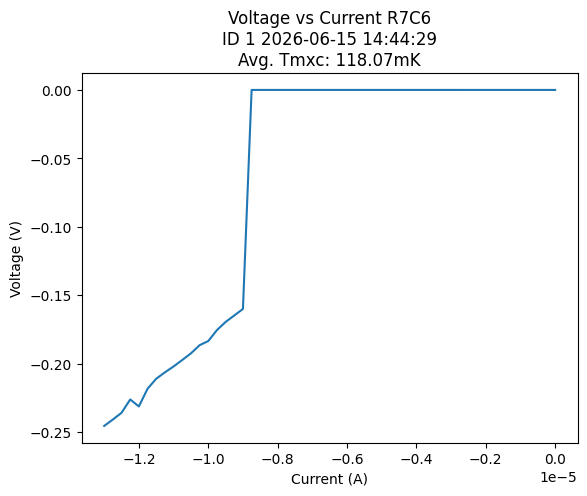

In [33]:
params.plot_critical_current(ID=1)

A way to get traces without splitting between IDs 

In [8]:
load_by_id(1).get_parameter_data().keys()

dict_keys(['MC_temp', 'dmm_volt'])

# To do 

* Make the device the input to every function
* Modularise counting function 

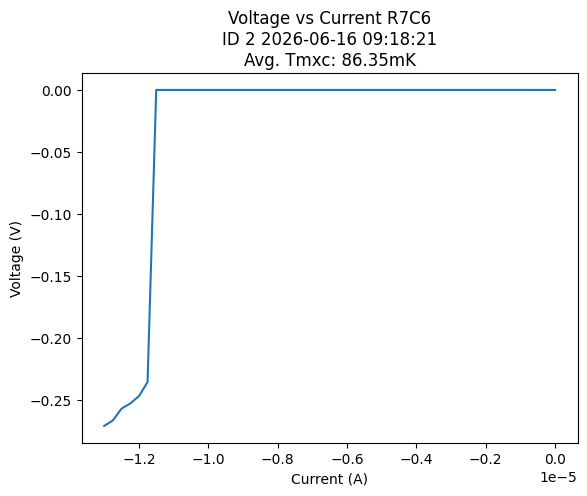

In [43]:
params.plot_critical_current(ID=2)

In [42]:
params.args(params.trace_vs_current)

(device, MS, dmm, yoko, trigger, v_scale, wait=120, currents=None, station=None)


In [74]:
np.isnan(data['yoko_current']['yoko_current'])

array([False, False, False, ...,  True,  True,  True], shape=(99375,))

In [77]:
int(data['h_samples']['h_samples'][0])

array([1875., 1875., 1875., ...,   nan,   nan,   nan], shape=(99375,))

In [78]:
99375/1875

53.0

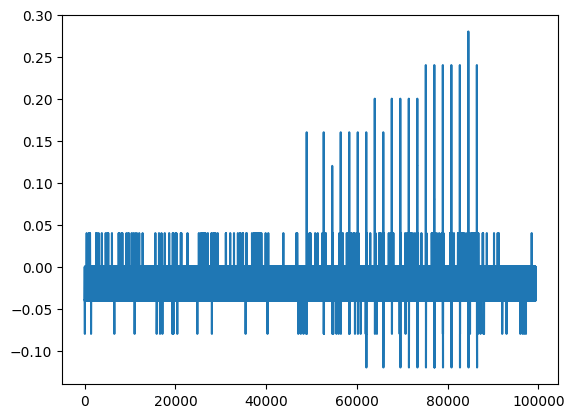

In [80]:
data = load_by_id(4).get_parameter_data()
plt.plot(data['trace']['trace'])
rows = len(data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])])
cols = int(data['h_samples']['h_samples'][0])
trace = np.reshape(data['trace']['trace'], (rows, cols))
# in the xarray thing the coordinates would be currents and time_axis and then everything else would be metadata/attributes

In [113]:
from scipy.signal import find_peaks
data = load_by_id(4).get_parameter_data()
trace = data['trace']['trace']


def plot_traces(idx, ID):
    data = load_by_id(ID).get_parameter_data()
    currents = data['yoko_current']['yoko_current']
    rows = len(currents[~np.isnan(currents)])
    cols = int(data['h_samples']['h_samples'][0])
    trigger = data['trigger']['trigger'][idx]
    v_scale = data['v_scale']['v_scale'][idx]
    trace = np.reshape(data['trace']['trace'], (rows, cols))[idx]
    time_axis = np.reshape(data['time_axis']['time_axis'], (rows, cols))[idx]
    current = currents[idx]
    # plotting the calibraiton parameters form last cooldown on these results 
    threshold1 = params.device_line_2['count_calibration']['threshold1'][idx]
    threshold2 = params.device_line_2['count_calibration']['threshold2'][idx]
    
    peaks, _ = find_peaks(trace, height=float(trigger), distance=len(trace))
    fig, ax = plt.subplots(1,1)
    ax.plot(time_axis, trace)
    ax.set_title(f'Current: {current} V_scale {v_scale}V Res {1e3*v_scale/25}mV')
    ax.plot(time_axis[peaks],trace[peaks], 'ro', label=f'Peak {trace[peaks]*1e3}mV')
    ax.axhline(trigger, label=f'Trigger {trigger*1e3}mV')
    ax.axhline(threshold1, label=f'T1 {threshold1*1e3}mV', color='r')
    ax.axhline(threshold2, label=f'T1 {threshold2*1e3}mV', color='m')
    ax.legend()

ID = 4                  
interact(plot_traces, idx=IntSlider(min=0, max=53, step=1, value=0,
                                continuous_update=False), ID=fixed(ID))

interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=53), Output()), _dom_…

<function __main__.plot_traces(idx, ID)>

In [109]:
params.device_line_2.keys()

dict_keys(['name', 'currents', 'count_calibration', 'counts_axes', 'IDs'])

In [67]:
rows = len(data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])])
cols = int(data['h_samples']['h_samples'][0])
trace = np.reshape(data['trace']['trace'], (rows, cols))

array([ 0.00e+00, -2.50e-07, -5.00e-07, -7.50e-07, -1.00e-06, -1.25e-06,
       -1.50e-06, -1.75e-06, -2.00e-06, -2.25e-06, -2.50e-06, -2.75e-06,
       -3.00e-06, -3.25e-06, -3.50e-06, -3.75e-06, -4.00e-06, -4.25e-06,
       -4.50e-06, -4.75e-06, -5.00e-06, -5.25e-06, -5.50e-06, -5.75e-06,
       -6.00e-06, -6.25e-06, -6.50e-06, -6.75e-06, -7.00e-06, -7.25e-06,
       -7.50e-06, -7.75e-06, -8.00e-06, -8.25e-06, -8.50e-06, -8.75e-06,
       -9.00e-06, -9.25e-06, -9.50e-06])

In [53]:
print(data['trigger']['trigger'][:len(params.device_line_2['currents'])])

[0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]


In [54]:
print(data['v_scale']['v_scale'][:len(params.device_line_2['currents'])])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


In [55]:
MS.channels[0].vertical_scale(150e-3)

NameError: name 'MS' is not defined

In [57]:
data = load_by_id(5).get_parameter_data()
print(data['v_scale']['v_scale'][:len(params.device_line_2['currents'])])
print(data['trigger']['trigger'][:len(params.device_line_2['currents'])])

[0.15 0.15  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
[0.048 0.102   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan]


These are correct. 

In [60]:
data = load_by_id(10).get_parameter_data()

In [63]:
data['CR1']['yoko_current']

array([ 0.00e+00, -2.50e-07, -5.00e-07, -7.50e-07, -1.00e-06, -1.25e-06,
       -1.50e-06, -1.75e-06, -2.00e-06, -2.25e-06, -2.50e-06, -2.75e-06,
       -3.00e-06, -3.25e-06, -3.50e-06, -3.75e-06, -4.00e-06, -4.25e-06,
       -4.50e-06, -4.75e-06, -5.00e-06, -5.25e-06, -5.50e-06, -5.75e-06,
       -6.00e-06, -6.25e-06, -6.50e-06, -6.75e-06, -7.00e-06, -7.25e-06,
       -7.50e-06, -7.75e-06, -8.00e-06, -8.25e-06, -8.50e-06, -8.75e-06,
       -9.00e-06, -9.25e-06, -9.50e-06])

In [64]:
data['threshold1']['threshold1']

array([0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192,
       0.024 , 0.0288, 0.0336, 0.0384, 0.0432, 0.048 , 0.0576, 0.0624,
       0.0624, 0.0672, 0.0768, 0.0816, 0.0816, 0.0912, 0.096 , 0.1008,
       0.1008, 0.1104, 0.1152, 0.12  , 0.1248, 0.1296, 0.1344, 0.144 ,
       0.144 , 0.1536, 0.1584, 0.1632, 0.1728, 0.1728, 0.1776,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      